In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
#Load the data
df = pd.read_csv("used_device_data.csv")
df.head()


,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [3]:
#Understand the data
# Basic info
df.info()

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Check data types
print("\nData types:\n", df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   device_brand           3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   rear_camera_mp         3275 non-null   float64
 6   front_camera_mp        3452 non-null   float64
 7   internal_memory        3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [4]:
#Preprocessing
# Replace yes/no with 1/0 if they exist
df.replace({'yes': 1, 'no': 0}, inplace=True)

# Drop irrelevant or highly cardinal columns
df.drop(columns=['model', 'Unnamed: 0'], inplace=True, errors='ignore')

# Encode categorical columns using one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


C:\Users\Kunal Ramesh Pawar\AppData\Local\Temp\ipykernel_9572\1217229342.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'yes': 1, 'no': 0}, inplace=True)


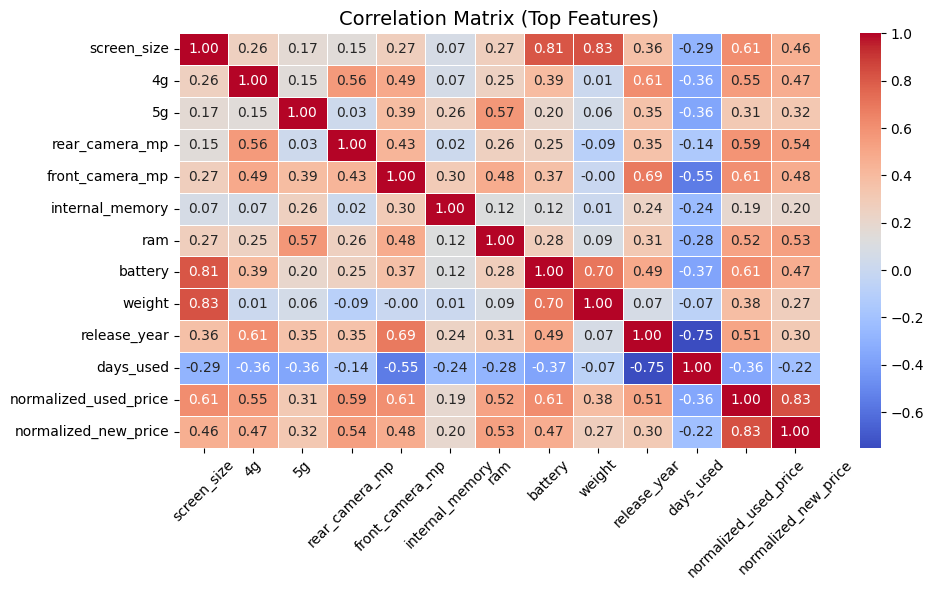

In [5]:
#Correlation Heatmap
plt.figure(figsize=(10, 6))

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Filter out columns that are not important or too many
# You can choose to include only a subset if too congested
correlation = numeric_df.corr()

# Plot
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title("Correlation Matrix (Top Features)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Define Features (X) and Target (y)
# Define target
y = df['normalized_used_price']

# Define features
X = df.drop('normalized_used_price', axis=1)


In [7]:
#Train-test Split
from sklearn.model_selection import train_test_split

# Splitting the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# Check for missing values again just to confirm
print("Missing values before handling:")
print(X_train.isnull().sum())

# Fill missing values with column mean (you can also use median or dropna)
X_train.fillna(X_train.mean(numeric_only=True), inplace=True)
X_test.fillna(X_test.mean(numeric_only=True), inplace=True)

# Confirm again
print("\nMissing values after handling:")
print(X_train.isnull().sum())


Missing values before handling:
screen_size                  0
4g                           0
5g                           0
rear_camera_mp             139
front_camera_mp              1
internal_memory              4
ram                          4
battery                      4
weight                       6
release_year                 0
days_used                    0
normalized_new_price         0
device_brand_Alcatel         0
device_brand_Apple           0
device_brand_Asus            0
device_brand_BlackBerry      0
device_brand_Celkon          0
device_brand_Coolpad         0
device_brand_Gionee          0
device_brand_Google          0
device_brand_HTC             0
device_brand_Honor           0
device_brand_Huawei          0
device_brand_Infinix         0
device_brand_Karbonn         0
device_brand_LG              0
device_brand_Lava            0
device_brand_Lenovo          0
device_brand_Meizu           0
device_brand_Micromax        0
device_brand_Microsoft       0
device_

In [9]:
#Train the Linear Regression Model
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Fit the model on training data
model.fit(X_train, y_train)


LinearRegression()

In [10]:
#Evaluate the Linear Regression Model
from sklearn.metrics import mean_absolute_error, r2_score

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): 0.18
R² Score: 0.84


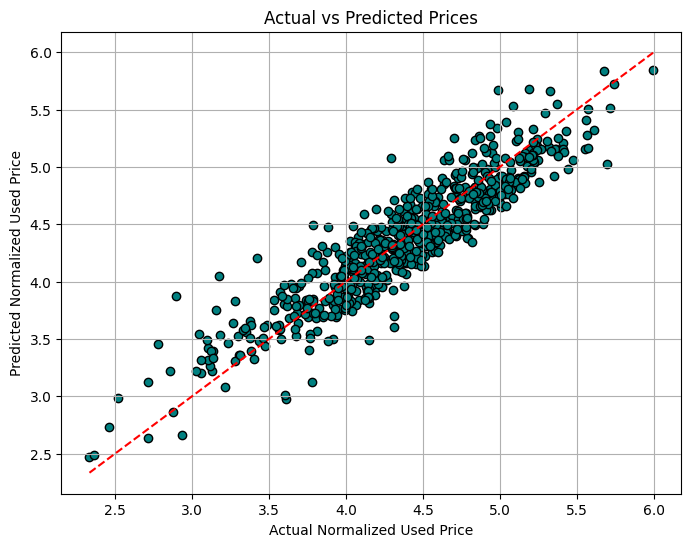

In [11]:
#Visualize Actual vs Predicted Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='teal', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Normalized Used Price")
plt.ylabel("Predicted Normalized Used Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()


 Plot Overview
X-axis: Actual normalized_used_price (from your dataset)

Y-axis: Predicted normalized_used_price (from the model)

Each dot represents a phone.

The red dashed line is the ideal line where predicted = actual (perfect predictions).

✅ What this tells us
Strong correlation:

Most points are close to the red line, meaning the model predicts the used prices quite accurately.

Some scatter:

A few points are off the line, which is expected in real-world data.

These are instances where the model slightly overestimated or underestimated.

No major outliers:

There aren’t many extreme points far from the line, so the model is stable and not heavily biased.

Good linear relationship:

This pattern confirms that a Linear Regression model is a good choice for this problem (at least as a baseline).

In [12]:
# Step 1: Predict using the trained model
predictions = model.predict(X_test)

# Step 2: Create a DataFrame for comparison
import pandas as pd
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': predictions
})

# Step 3: Display first few rows
print(comparison_df.head())


   Actual Price  Predicted Price
0      3.974246         3.866294
1      5.001191         4.924455
2      4.562054         4.319968
3      4.176232         4.049439
4      3.156149         3.752289
